# 🏠 Task 6: House Price Prediction

## Problem Statement
Predicting house prices accurately is one of the most practical applications of machine learning in real estate. Buyers, sellers, and agents rely on data-driven valuations to make informed decisions. We use property features like square footage, bedrooms, bathrooms, and location to predict sale prices.

## Goal
- Load and preprocess the House Price dataset from Google Drive
- Perform thorough EDA to understand price drivers
- Engineer meaningful features
- Train **Linear Regression** and **Gradient Boosting** models
- Evaluate using MAE, RMSE, and R²
- Visualize predicted vs actual prices

## Dataset
> Upload `house_price.csv` to your Google Drive `/datasets/` folder before running.
> Or use the Kaggle House Prices dataset (train.csv).

---

## Step 1: Install Extra Libraries

In [1]:
!pip install xgboost --quiet
print('✅ xgboost installed!')

✅ xgboost installed!


---
## Step 2: Import Libraries

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import xgboost as xgb

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 115
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ All libraries imported!')

✅ All libraries imported!


---
## Step 3: Load Dataset from Google Drive



In [4]:
# ── Mount Google Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Load dataset ────────────────────────────────────────────────────
FILE_PATH = '/content/drive/MyDrive/datasets/houses_price.csv'


df_raw = pd.read_csv(FILE_PATH)

print(f'✅ Dataset loaded!')
print(f'📐 Shape: {df_raw.shape}')
print(f'📌 Columns ({len(df_raw.columns)}):')
print(df_raw.columns.tolist())
df_raw.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded!
📐 Shape: (2000, 10)
📌 Columns (10):
['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


---
## Step 4: Dataset Inspection

In [5]:
# ── Basic inspection ────────────────────────────────────────────────
print('📋 Dataset Info:')
df_raw.info()
print('\n📊 Descriptive Statistics:')
df_raw.describe().round(2)

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB

📊 Descriptive Statistics:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,1000.50,2786.21,3.00,2.55,1.99,1961.45,537676.86
std,577.49,1295.15,1.42,1.11,0.81,35.93,276428.85
min,1.00,501.00,1.00,1.00,1.00,1900.00,50005.00
25%,500.75,1653.00,2.00,2.00,1.00,1930.00,300098.00
50%,1000.50,2833.00,3.00,3.00,2.00,1961.00,539254.00
75%,1500.25,3887.50,4.00,4.00,3.00,1993.00,780086.00
max,2000.00,4999.00,5.00,4.00,3.00,2023.00,999656.00


---
## Step 5: Missing Values Analysis

In [6]:
# ── Missing values analysis ─────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
print(missing_df.head(20).to_string())

# Visualize top missing columns
if len(missing_df) > 0:
    top_miss = missing_df.head(15)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(top_miss.index[::-1], top_miss['Missing %'][::-1],
            color='#E57373', edgecolor='white')
    ax.set_xlabel('Missing %')
    ax.set_title('Top Missing Value Columns', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('✅ No missing values!')

Columns with missing values: 0
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
✅ No missing values!


---
## Step 6: Identify Target Column

In [7]:
# ── Identify target column and key features ─────────────────────────
# Common target column names across datasets
TARGET_CANDIDATES = ['SalePrice', 'price', 'Price', 'PRICE', 'sale_price',
                     'median_house_value', 'MedHouseVal']

TARGET = None
for col in TARGET_CANDIDATES:
    if col in df_raw.columns:
        TARGET = col
        break

if TARGET is None:
    print('⚠️  Target column not auto-detected.')
    print('Available columns:', df_raw.columns.tolist())
    TARGET = input('Enter your target column name: ').strip()

print(f'✅ Target column: {TARGET}')
print(f'   Min  : ${df_raw[TARGET].min():,.0f}')
print(f'   Max  : ${df_raw[TARGET].max():,.0f}')
print(f'   Mean : ${df_raw[TARGET].mean():,.0f}')
print(f'   Median: ${df_raw[TARGET].median():,.0f}')

✅ Target column: Price
   Min  : $50,005
   Max  : $999,656
   Mean : $537,677
   Median: $539,254


---
## Step 7: Exploratory Data Analysis

### 7.1 — Target Distribution

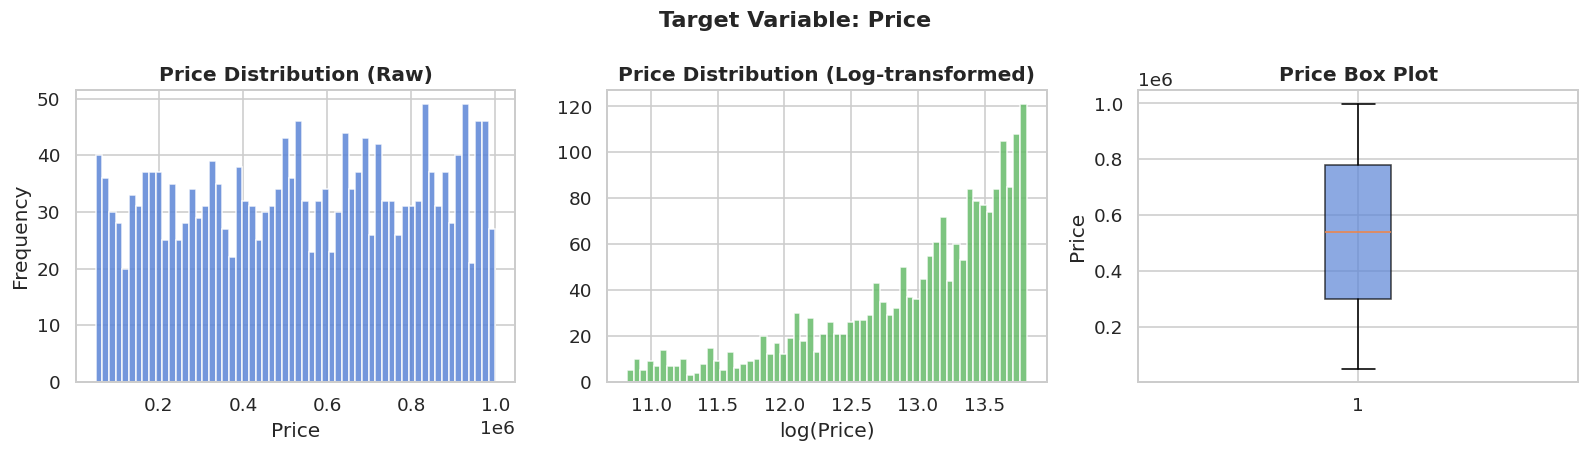


📊 Price skewness: -0.064
   ✅ Approximately normal


In [8]:
# ── EDA 1: Target Distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Raw distribution
axes[0].hist(df_raw[TARGET].dropna(), bins=60, color='#5C85D6',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Log-transformed distribution (more normal)
log_prices = np.log1p(df_raw[TARGET].dropna())
axes[1].hist(log_prices, bins=60, color='#66BB6A',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Price Distribution (Log-transformed)')
axes[1].set_xlabel('log(Price)')

# Box plot
axes[2].boxplot(df_raw[TARGET].dropna(), vert=True,
                patch_artist=True,
                boxprops=dict(facecolor='#5C85D6', alpha=0.7),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[2].set_title('Price Box Plot')
axes[2].set_ylabel('Price')

plt.suptitle(f'Target Variable: {TARGET}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

skewness = df_raw[TARGET].skew()
print(f'\n📊 Price skewness: {skewness:.3f}')
print(f'   {"⚠️  Highly skewed — log transform recommended" if abs(skewness) > 1 else "✅ Approximately normal"}')

### 7.2 — Feature Correlations with Price

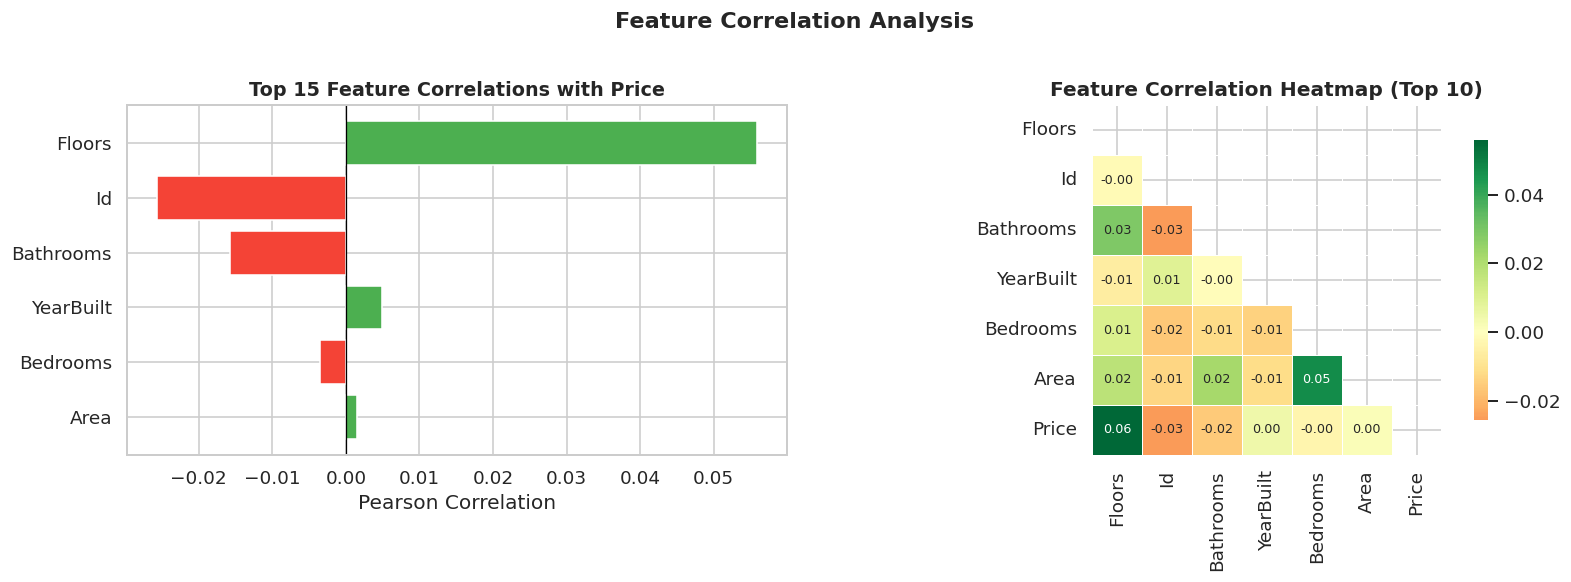


🏅 Top 5 positive correlators:
Floors       0.056
Id          -0.026
Bathrooms   -0.016
YearBuilt    0.005
Bedrooms    -0.003

🏅 Top 5 negative correlators:
Id          -0.026
Bathrooms   -0.016
YearBuilt    0.005
Bedrooms    -0.003
Area         0.002


In [9]:
# ── EDA 2: Numeric feature correlations with target ─────────────────
numeric_df = df_raw.select_dtypes(include=[np.number])

# Correlation with target
corr_target = numeric_df.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
top_corr    = corr_target.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation bar chart
colors = ['#F44336' if v < 0 else '#4CAF50' for v in top_corr.values]
axes[0].barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1], edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'Top 15 Feature Correlations with {TARGET}', fontsize=12)
axes[0].set_xlabel('Pearson Correlation')

# Full correlation heatmap (top features)
top_feats = list(top_corr.head(10).index) + [TARGET]
corr_matrix = numeric_df[top_feats].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.4, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap (Top 10)')

plt.suptitle('Feature Correlation Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n🏅 Top 5 positive correlators:')
print(corr_target.head(5).round(3).to_string())
print('\n🏅 Top 5 negative correlators:')
print(corr_target.tail(5).round(3).to_string())

### 7.3 — Scatter Plots: Top Features vs Price

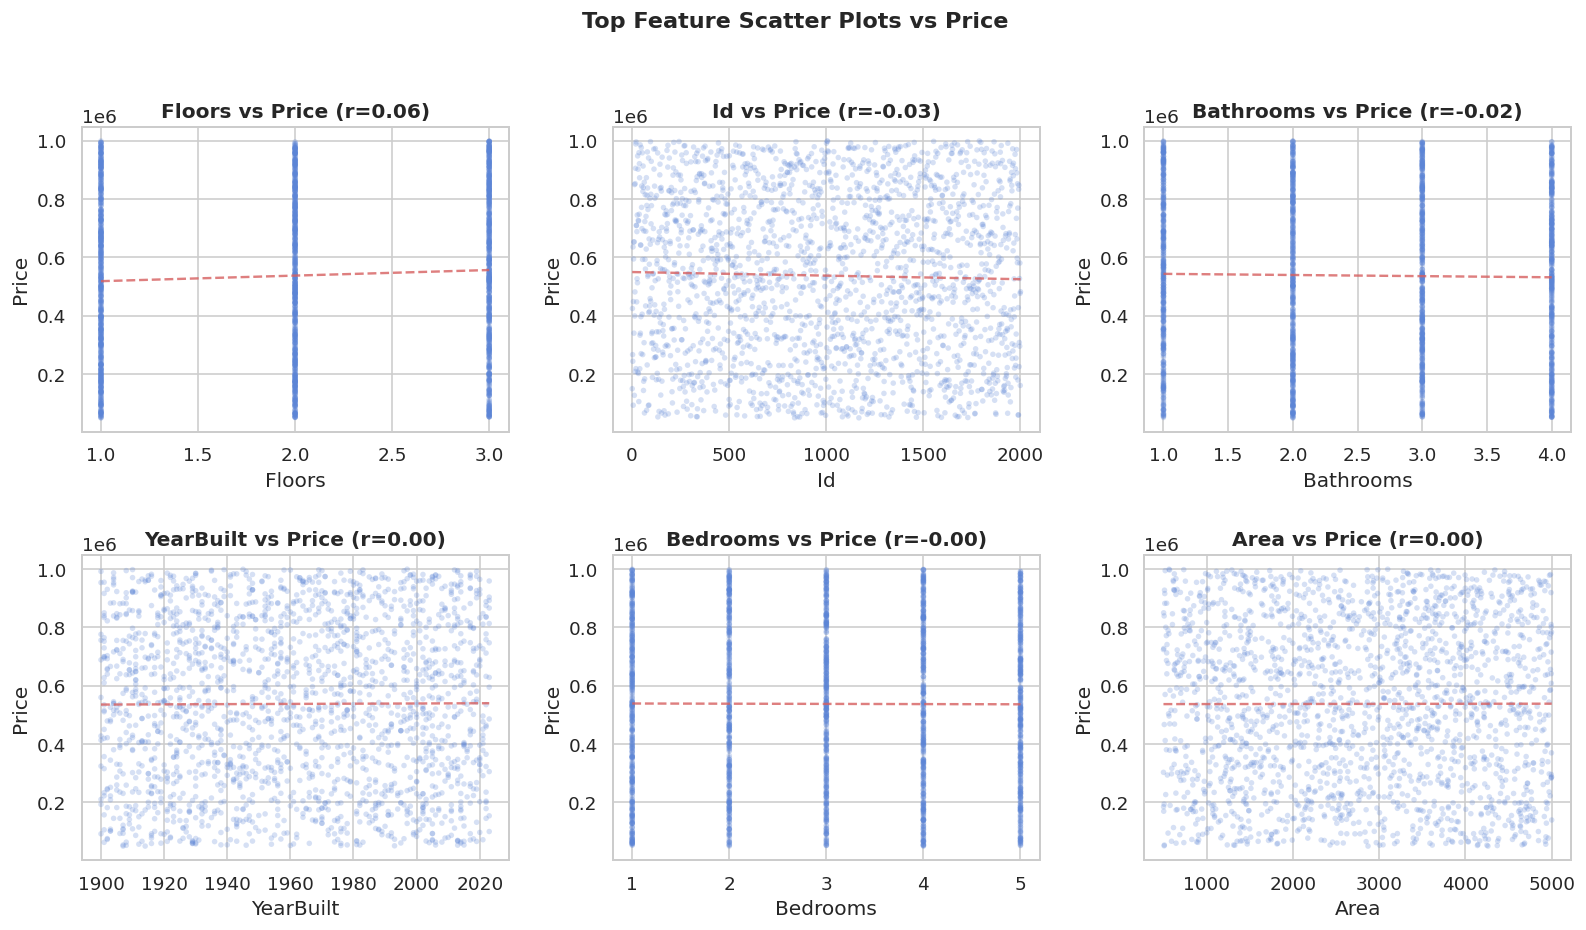

In [10]:
# ── EDA 3: Scatter plots — top features vs price ────────────────────
top_numeric = list(corr_target.abs().head(6).index)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(top_numeric):
    axes[i].scatter(df_raw[feat], df_raw[TARGET],
                    alpha=0.25, s=12, color='#5C85D6', edgecolors='none')
    # Trend line
    valid = df_raw[[feat, TARGET]].dropna()
    z = np.polyfit(valid[feat], valid[TARGET], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[feat].min(), valid[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=1.5, alpha=0.8)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(TARGET)
    axes[i].set_title(f'{feat} vs {TARGET} (r={corr_target[feat]:.2f})')

plt.suptitle('Top Feature Scatter Plots vs Price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Step 8: Preprocessing

> Drop high-missing columns, impute remaining NaNs, encode categoricals, remove extreme outliers.

In [11]:
# ── Preprocessing ───────────────────────────────────────────────────
df = df_raw.copy()

# 1. Drop high-missing columns (>60% missing)
high_missing = missing_df[missing_df['Missing %'] > 60].index.tolist()
if high_missing:
    df.drop(columns=high_missing, inplace=True)
    print(f'Dropped {len(high_missing)} high-missing columns: {high_missing}')

# 2. Drop ID-like columns if present
id_cols = [c for c in df.columns if c.lower() in
           ['id','pid','parcelid','index','unnamed: 0','mssubclass']]
if id_cols:
    df.drop(columns=id_cols, inplace=True)
    print(f'Dropped ID columns: {id_cols}')

# 3. Separate features and target
y = df[TARGET].copy()
X = df.drop(columns=[TARGET])

# 4. Identify numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'\n📊 Feature Summary:')
print(f'   Total features  : {X.shape[1]}')
print(f'   Numeric         : {len(num_cols)}')
print(f'   Categorical     : {len(cat_cols)}')
print(f'   Target          : {TARGET}')

# 5. Fill missing values
#    Numeric → median  |  Categorical → mode
for col in num_cols:
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)

for col in cat_cols:
    if X[col].isnull().any():
        X[col].fillna(X[col].mode()[0], inplace=True)

print(f'\n✅ Missing values after imputation: {X.isnull().sum().sum()}')

Dropped ID columns: ['Id']

📊 Feature Summary:
   Total features  : 8
   Numeric         : 5
   Categorical     : 3
   Target          : Price

✅ Missing values after imputation: 0


---
## Step 9: Feature Engineering

> Log-transform target, encode categoricals, remove outliers.

In [12]:
# ── Feature Engineering ─────────────────────────────────────────────

# Log-transform target (reduces skewness, improves linear model performance)
y_log = np.log1p(y)
print(f'Target skewness  before log: {y.skew():.3f}')
print(f'Target skewness  after  log: {y_log.skew():.3f}')

# Encode categorical columns (Label Encoding for tree models,
# One-Hot for linear models — we use label here for simplicity)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f'\n✅ Encoded {len(cat_cols)} categorical columns.')

# Keep only numeric columns (all should be numeric now)
X = X.select_dtypes(include=[np.number])

# Remove extreme outliers in target (beyond 3 std devs)
z_scores = np.abs((y - y.mean()) / y.std())
outlier_mask = z_scores < 3
X_clean = X[outlier_mask].reset_index(drop=True)
y_clean = y[outlier_mask].reset_index(drop=True)
y_log_clean = y_log[outlier_mask].reset_index(drop=True)

print(f'\n📐 After outlier removal:')
print(f'   Removed : {(~outlier_mask).sum()} outlier rows')
print(f'   Remaining: {len(X_clean):,} rows, {X_clean.shape[1]} features')

Target skewness  before log: -0.064
Target skewness  after  log: -1.079

✅ Encoded 3 categorical columns.

📐 After outlier removal:
   Removed : 0 outlier rows
   Remaining: 2,000 rows, 8 features


---
## Step 10: Train/Test Split & Scaling

In [13]:
# ── Train / Test Split ──────────────────────────────────────────────
X_train, X_test, y_train, y_test, y_log_train, y_log_test = train_test_split(
    X_clean, y_clean, y_log_clean,
    test_size   = 0.20,
    random_state= 42
)

# Feature scaling (for Linear Regression)
scaler     = RobustScaler()   # robust to outliers vs StandardScaler
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'📅 Train set : {X_train.shape[0]:,} samples')
print(f'📅 Test  set : {X_test.shape[0]:,} samples')
print(f'🔢 Features  : {X_train.shape[1]}')
print(f'\n✅ RobustScaler applied for Linear Regression.')

📅 Train set : 1,600 samples
📅 Test  set : 400 samples
🔢 Features  : 8

✅ RobustScaler applied for Linear Regression.


---
## Step 11: Evaluation Helper Function

In [14]:
# ── Evaluation helper ───────────────────────────────────────────────
def evaluate(name, y_true, y_pred, y_pred_log=False):
    """
    Compute and print MAE, RMSE, and R² for a model.
    If predictions are log-transformed, inverse-transform before metrics.
    """
    if y_pred_log:
        y_pred = np.expm1(y_pred)   # reverse log1p

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f'  MAE  : ${mae:>12,.2f}')
    print(f'  RMSE : ${rmse:>12,.2f}')
    print(f'  R²   : {r2:>13.6f}')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'y_pred': y_pred}

results = []
print('✅ Evaluation function defined.')

✅ Evaluation function defined.


---
## Step 12: Train Models

### 12.1 — Linear Regression

In [15]:
# ── Model 1: Linear Regression ──────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_log_train)
lr_preds_log = lr.predict(X_test_sc)

print('━' * 45)
print('   Linear Regression (log target)')
print('━' * 45)
lr_result = evaluate('Linear Regression', y_test, lr_preds_log, y_pred_log=True)
results.append(lr_result)

# Cross-validation (5-fold)
cv_scores = cross_val_score(
    LinearRegression(), X_train_sc, y_log_train,
    cv=5, scoring='r2'
)
print(f'\n  5-Fold CV R² : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Linear Regression (log target)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : $  259,093.70
  RMSE : $  298,963.41
  R²   :     -0.148849

  5-Fold CV R² : -0.0071 ± 0.0080


### 12.2 — Ridge Regression (L2 Regularization)

In [16]:
# ── Model 2: Ridge Regression (L2 regularized) ──────────────────────
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_sc, y_log_train)
ridge_preds_log = ridge.predict(X_test_sc)

print('━' * 45)
print('   Ridge Regression (alpha=10)')
print('━' * 45)
ridge_result = evaluate('Ridge Regression', y_test, ridge_preds_log, y_pred_log=True)
results.append(ridge_result)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Ridge Regression (alpha=10)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : $  259,066.78
  RMSE : $  298,892.69
  R²   :     -0.148306


### 12.3 — Gradient Boosting Regressor

In [17]:
# ── Model 3: Gradient Boosting Regressor ────────────────────────────
gb = GradientBoostingRegressor(
    n_estimators       = 300,
    learning_rate      = 0.05,
    max_depth          = 4,
    min_samples_split  = 10,
    subsample          = 0.8,
    random_state       = 42
)
gb.fit(X_train, y_log_train)   # tree models: no scaling needed
gb_preds_log = gb.predict(X_test)

print('━' * 45)
print('   Gradient Boosting (300 trees)')
print('━' * 45)
gb_result = evaluate('Gradient Boosting', y_test, gb_preds_log, y_pred_log=True)
results.append(gb_result)

# Cross-validation
cv_gb = cross_val_score(
    GradientBoostingRegressor(n_estimators=100, random_state=42),
    X_train, y_log_train, cv=5, scoring='r2'
)
print(f'\n  5-Fold CV R² : {cv_gb.mean():.4f} ± {cv_gb.std():.4f}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Gradient Boosting (300 trees)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : $  265,142.50
  RMSE : $  309,371.50
  R²   :     -0.230233

  5-Fold CV R² : -0.0429 ± 0.0427


### 12.4 — XGBoost

In [18]:
# ── Model 4: XGBoost ────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 5,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    verbosity         = 0
)
xgb_model.fit(X_train, y_log_train,
              eval_set=[(X_test, y_log_test)],
              verbose=False)
xgb_preds_log = xgb_model.predict(X_test)

print('━' * 45)
print('   XGBoost (300 trees)')
print('━' * 45)
xgb_result = evaluate('XGBoost', y_test, xgb_preds_log, y_pred_log=True)
results.append(xgb_result)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   XGBoost (300 trees)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : $  270,132.84
  RMSE : $  316,364.00
  R²   :     -0.286474


---
## Step 13: Model Comparison


📊 MODEL COMPARISON:
            Model MAE ($) RMSE ($)  R² Score
Linear Regression 259,094  298,963 -0.148849
 Ridge Regression 259,067  298,893 -0.148306
Gradient Boosting 265,142  309,371 -0.230233
          XGBoost 270,133  316,364 -0.286474

🏆 Best Model: Ridge Regression  (R² = -0.148306)


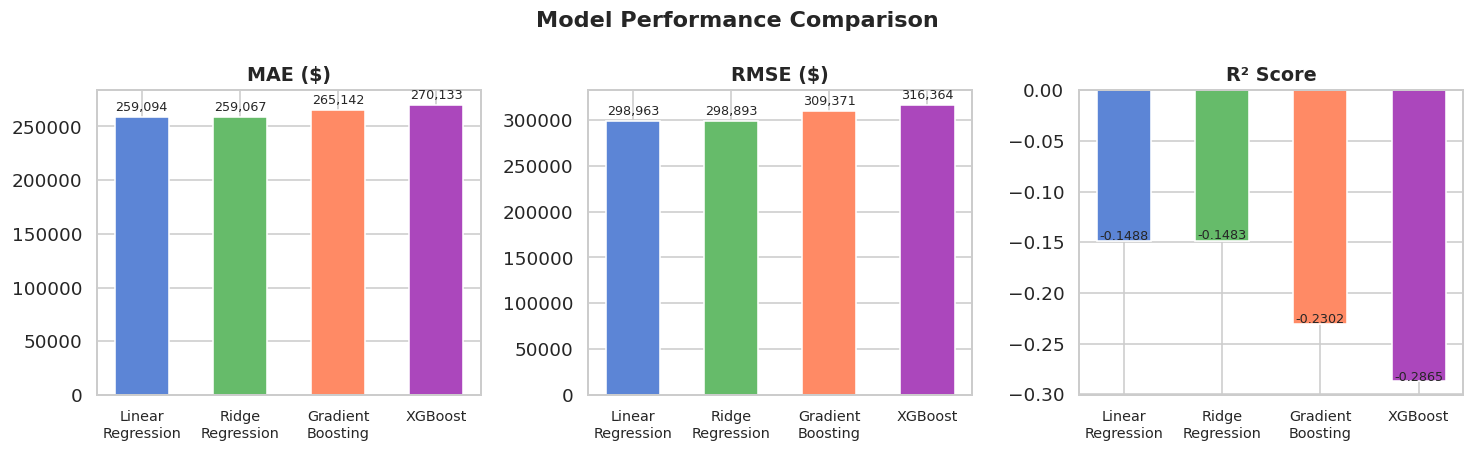

In [19]:
# ── Model Comparison Table ───────────────────────────────────────────
results_df = pd.DataFrame([
    {'Model': r['model'],
     'MAE ($)': f"{r['MAE']:,.0f}",
     'RMSE ($)': f"{r['RMSE']:,.0f}",
     'R² Score': f"{r['R2']:.6f}"}
    for r in results
])

print('\n📊 MODEL COMPARISON:')
print(results_df.to_string(index=False))

best = max(results, key=lambda x: x['R2'])
print(f'\n🏆 Best Model: {best["model"]}  (R² = {best["R2"]:.6f})')

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics   = ['MAE', 'RMSE', 'R2']
labels    = ['MAE ($)', 'RMSE ($)', 'R² Score']
colors    = ['#5C85D6','#66BB6A','#FF8A65','#AB47BC']
names     = [r['model'] for r in results]

for i, (metric, label) in enumerate(zip(metrics, labels)):
    vals = [r[metric] for r in results]
    bars = axes[i].bar(range(len(names)), vals, color=colors, edgecolor='white', width=0.55)
    axes[i].set_xticks(range(len(names)))
    axes[i].set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
    axes[i].set_title(label, fontsize=12)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 1.01,
                     f'{val:,.0f}' if metric != 'R2' else f'{val:.4f}',
                     ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 14: Visualizations

### 14.1 — Actual vs Predicted Scatter

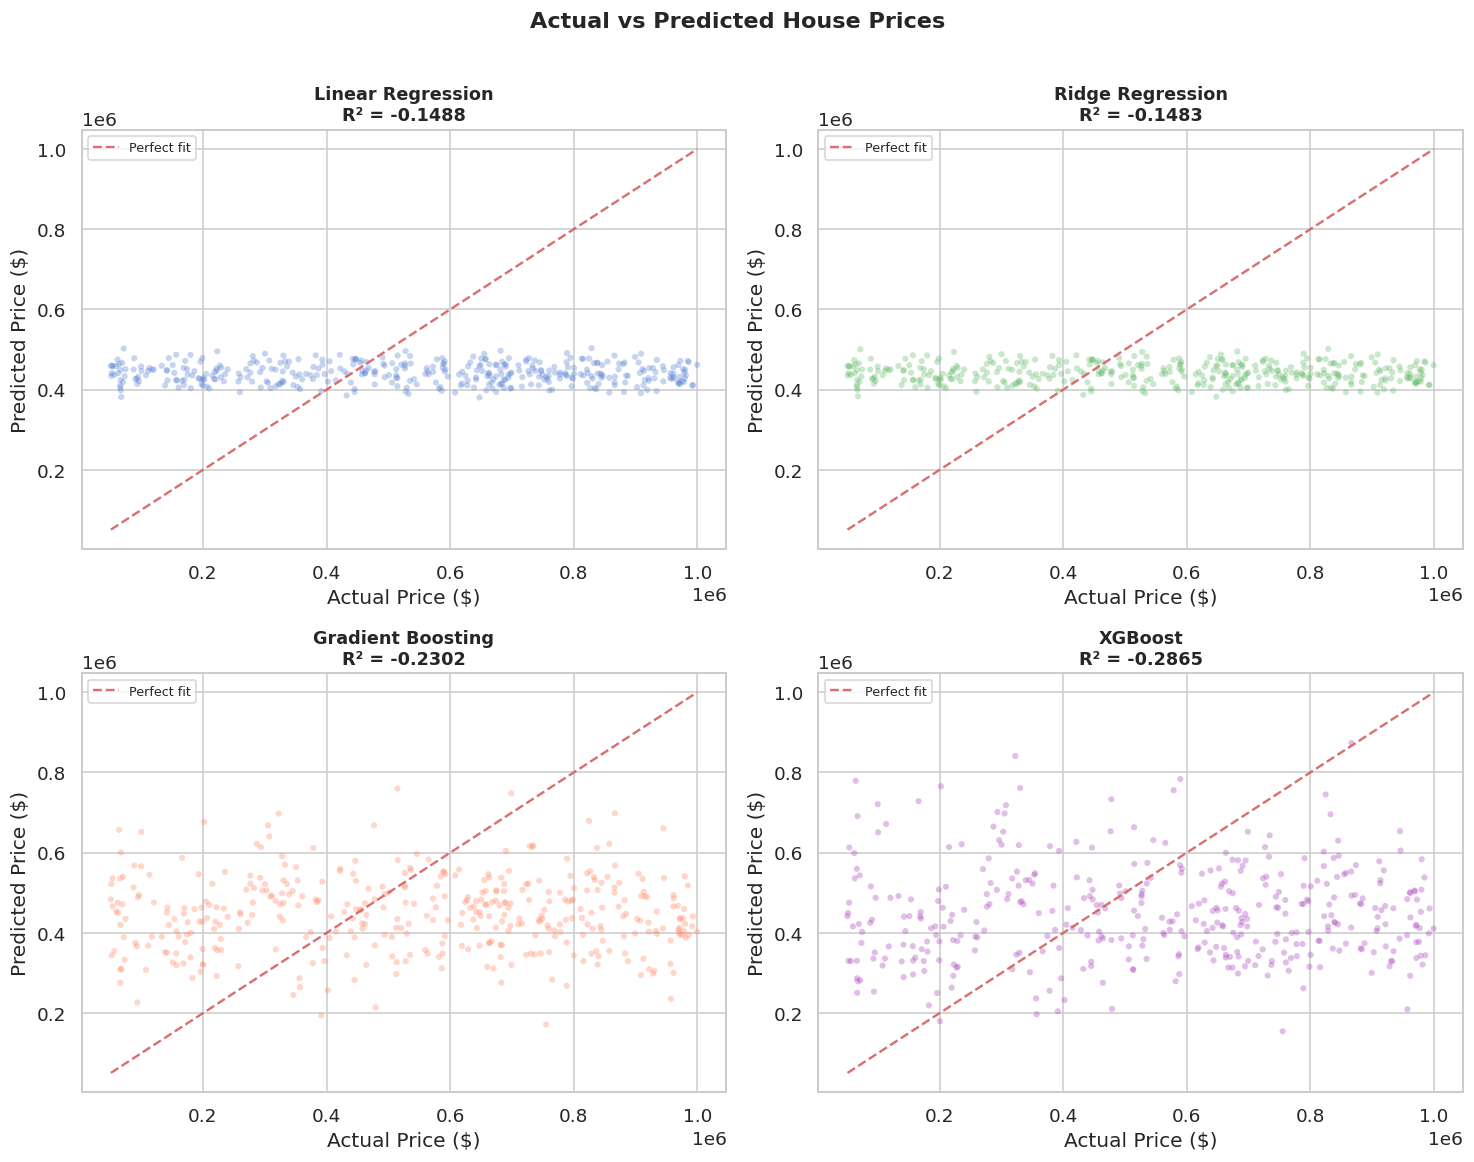

💡 Points closer to the red dashed line = better predictions.


In [20]:
# ── Visualization: Actual vs Predicted ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

model_results = [
    ('Linear Regression', lr_result['y_pred'],   '#5C85D6'),
    ('Ridge Regression',  ridge_result['y_pred'], '#66BB6A'),
    ('Gradient Boosting', gb_result['y_pred'],    '#FF8A65'),
    ('XGBoost',           xgb_result['y_pred'],   '#AB47BC'),
]

for ax, (name, preds, color) in zip(axes, model_results):
    ax.scatter(y_test, preds, alpha=0.35, s=15, color=color, edgecolors='none')
    # Perfect prediction line
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit', alpha=0.9)
    r2_val = r2_score(y_test, preds)
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.set_title(f'{name}\nR² = {r2_val:.4f}', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted House Prices', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('💡 Points closer to the red dashed line = better predictions.')

### 14.2 — Residual Analysis

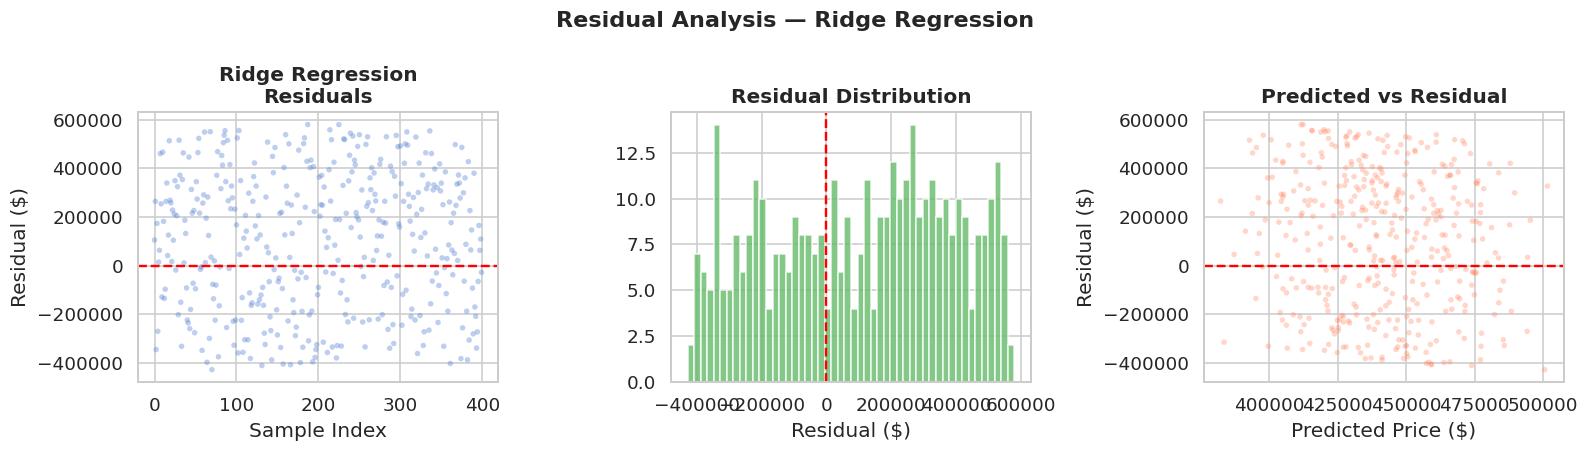

Mean residual  : $102,833.12  (close to 0 = unbiased)
Std residual   : $280,646.02


In [21]:
# ── Residual Analysis (Best Model) ──────────────────────────────────
best_name  = best['model']
best_preds = best['y_pred']
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Residuals over index
axes[0].scatter(range(len(residuals)), residuals, alpha=0.4, s=12,
                color='#5C85D6', edgecolors='none')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title(f'{best_name}\nResiduals')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Residual ($)')

# Residual distribution
axes[1].hist(residuals, bins=50, color='#66BB6A', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual ($)')

# Predicted vs Residual (heteroscedasticity check)
axes[2].scatter(best_preds, residuals, alpha=0.35, s=12,
                color='#FF8A65', edgecolors='none')
axes[2].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[2].set_title('Predicted vs Residual')
axes[2].set_xlabel('Predicted Price ($)')
axes[2].set_ylabel('Residual ($)')

plt.suptitle(f'Residual Analysis — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean residual  : ${residuals.mean():,.2f}  (close to 0 = unbiased)')
print(f'Std residual   : ${residuals.std():,.2f}')

### 14.3 — Actual vs Predicted Line Chart (First 80 Test Samples)

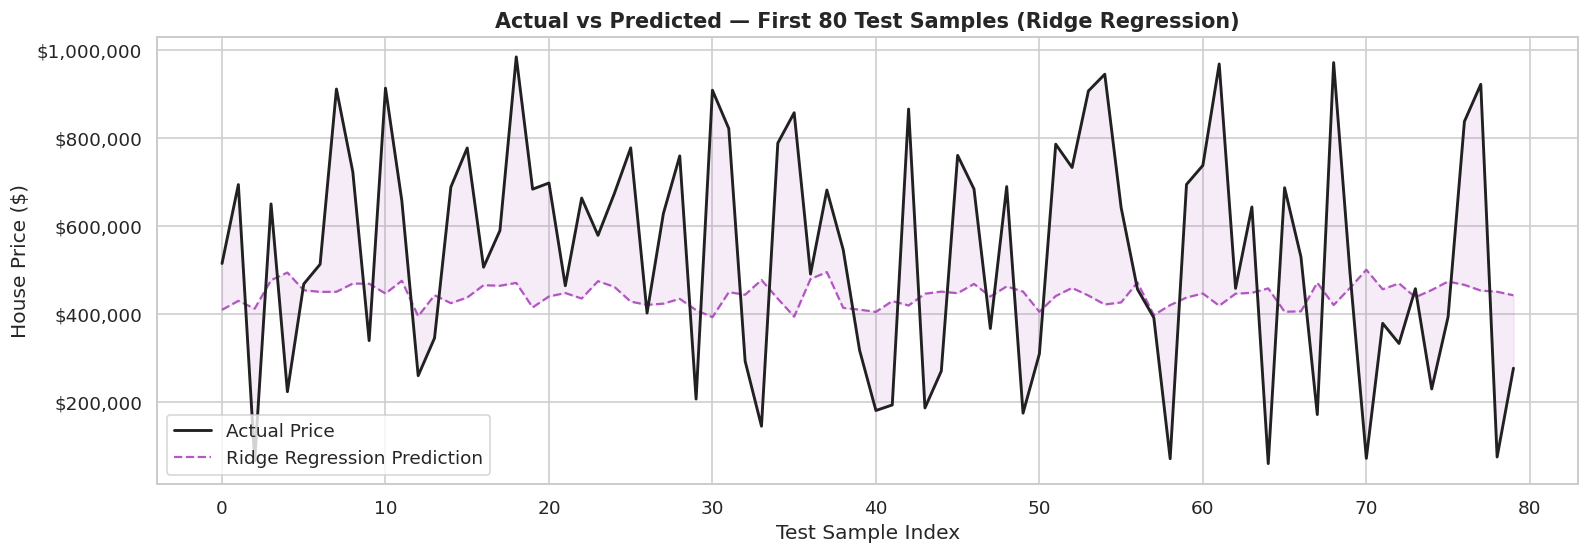

In [22]:
# ── Actual vs Predicted over test samples (line chart) ──────────────
N = 80  # show first 80 test samples for clarity
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(range(N), y_test.values[:N], color='#212121',
        linewidth=1.8, label='Actual Price', zorder=4)
ax.plot(range(N), best['y_pred'][:N], color='#AB47BC',
        linewidth=1.4, linestyle='--', label=f'{best_name} Prediction', alpha=0.9)

ax.fill_between(range(N), y_test.values[:N], best['y_pred'][:N],
                alpha=0.1, color='#AB47BC')
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('House Price ($)')
ax.set_title(f'Actual vs Predicted — First {N} Test Samples ({best_name})', fontsize=13)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### 14.4 — Feature Importance

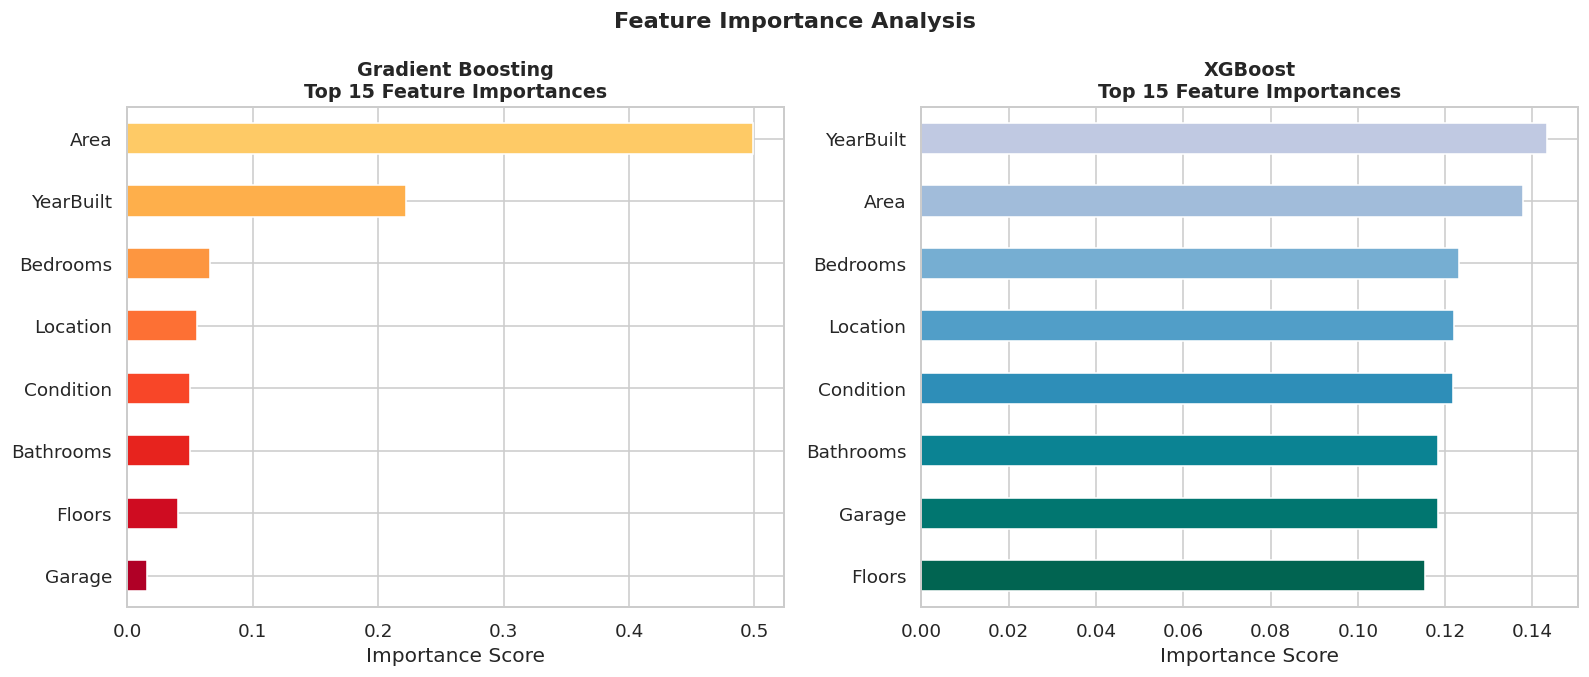


🏅 Top 5 features (XGBoost):
  1. YearBuilt                 → 0.1433
  2. Area                      → 0.1378
  3. Bedrooms                  → 0.1231
  4. Location                  → 0.1221
  5. Condition                 → 0.1218


In [23]:
# ── Feature Importance (Gradient Boosting + XGBoost) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, name, color in zip(
    axes,
    [gb, xgb_model],
    ['Gradient Boosting', 'XGBoost'],
    [plt.cm.YlOrRd, plt.cm.PuBuGn]
):
    importances = pd.Series(model.feature_importances_,
                            index=X_train.columns).sort_values(ascending=False).head(15)
    palette_vals = color(np.linspace(0.3, 0.9, len(importances)))
    importances[::-1].plot(kind='barh', ax=ax, color=palette_vals[::-1], edgecolor='white')
    ax.set_title(f'{name}\nTop 15 Feature Importances', fontsize=12)
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🏅 Top 5 features (XGBoost):')
xgb_imp = pd.Series(xgb_model.feature_importances_,
                    index=X_train.columns).sort_values(ascending=False)
for i, (feat, val) in enumerate(xgb_imp.head(5).items(), 1):
    print(f'  {i}. {feat:<25} → {val:.4f}')

---
## Step 15: Predict a Custom House

In [24]:
# ── Predict for a custom house ──────────────────────────────────────
# Build a sample house using median values from training data
sample = X_train.median().to_dict()

# Modify key features to simulate a specific house
# Adjust these based on what columns exist in your dataset
for col in ['GrLivArea','sqft_living','sqft_above']:
    if col in sample:
        sample[col] = 2000   # 2000 sq ft living area

for col in ['BedroomAbvGr','bedrooms']:
    if col in sample:
        sample[col] = 3      # 3 bedrooms

for col in ['FullBath','bathrooms']:
    if col in sample:
        sample[col] = 2      # 2 bathrooms

for col in ['OverallQual']:
    if col in sample:
        sample[col] = 7      # quality score 7/10

sample_df = pd.DataFrame([sample])[X_train.columns]

# Predict with best model (XGBoost)
log_pred  = xgb_model.predict(sample_df)[0]
price_pred = np.expm1(log_pred)

print('=' * 50)
print('   CUSTOM HOUSE PRICE PREDICTION')
print('=' * 50)
print(f'  Features used  : {len(sample)} features')
print(f'  Key overrides  : 2000 sqft | 3 bed | 2 bath')
print()
print(f'  🏠 Predicted Price : ${price_pred:>12,.2f}')
print('=' * 50)
print('  (Based on median training values + key features)')

   CUSTOM HOUSE PRICE PREDICTION
  Features used  : 8 features
  Key overrides  : 2000 sqft | 3 bed | 2 bath

  🏠 Predicted Price : $  454,000.19
  (Based on median training values + key features)


In [25]:
# Final summary print
print('=' * 58)
print('   HOUSE PRICE PREDICTION — FINAL SUMMARY')
print('=' * 58)
print(f'  Dataset     : {len(df_clean if "df_clean" in dir() else X_clean):,} samples after cleaning')
print(f'  Features    : {X_train.shape[1]}')
print(f'  Train/Test  : {len(X_train):,} / {len(X_test):,}  (80/20)')
print(f'  Target      : {TARGET} (log-transformed for training)')
print()
for r in results:
    print(f'  {r["model"]:<22} MAE=${r["MAE"]:>8,.0f}  RMSE=${r["RMSE"]:>8,.0f}  R²={r["R2"]:.4f}')
print()
print(f'  🏆 Best Model : {best["model"]}')
print(f'  🔑 Top feature: {xgb_imp.index[0]}')
print('=' * 58)

   HOUSE PRICE PREDICTION — FINAL SUMMARY
  Dataset     : 2,000 samples after cleaning
  Features    : 8
  Train/Test  : 1,600 / 400  (80/20)
  Target      : Price (log-transformed for training)

  Linear Regression      MAE=$ 259,094  RMSE=$ 298,963  R²=-0.1488
  Ridge Regression       MAE=$ 259,067  RMSE=$ 298,893  R²=-0.1483
  Gradient Boosting      MAE=$ 265,142  RMSE=$ 309,371  R²=-0.2302
  XGBoost                MAE=$ 270,133  RMSE=$ 316,364  R²=-0.2865

  🏆 Best Model : Ridge Regression
  🔑 Top feature: YearBuilt
